# Sentiment analysis on movie reviews

In this notebook, we will explore basic NLP techniques to analyze movie reviews using the Large Movie Review Dataset, found in: https://ai.stanford.edu/~amaas/data/sentiment/

In [1]:
from collections import Counter

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

import os

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
import re

In [2]:
def load_imdb_data(path):
    data = []
    labels = []
    for label in ['pos', 'neg']:
        dir_path = f"{path}/{label}"
        for filename in os.listdir(dir_path):
            with open(f"{dir_path}/{filename}", 'r', encoding='utf-8') as file:
                data.append(file.read())
                labels.append(1 if label == 'pos' else 0)
    return pd.DataFrame({'review': data, 'sentiment': labels})

In [6]:
# Dataset
!unzip -q aclImdb.zip

In [8]:
# Borra lo innecesario
!rm -rf __MACOSX
!find aclImdb -name ".DS_Store" -delete

In [10]:
# Change this to the path where you unzipped the dataset
dataset_root = "aclImdb"

train_df = load_imdb_data(dataset_root + "/train")
test_df = load_imdb_data(dataset_root + "/test")

## EDA

Let's take a quick look at the data to understand the distribution of sentiments, the length of reviews, and some common words used in positive vs negative reviews.

<Axes: xlabel='sentiment', ylabel='count'>

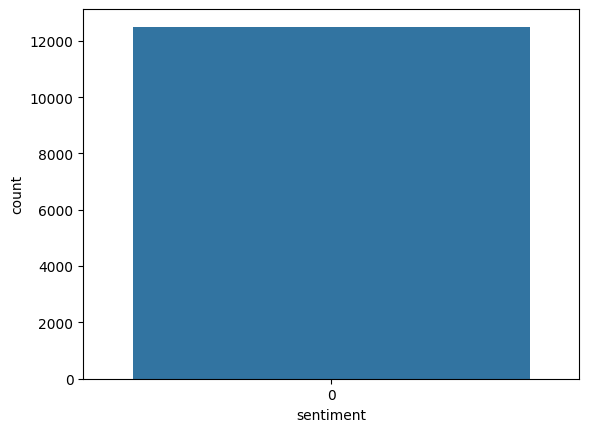

In [11]:
sns.countplot(x='sentiment', data=train_df)

As we can see, the dataset is balanced with an equal number of positive and negative reviews.

Let's now look at the distribution of review lengths. First compute the length of each review, both in terms of characters and words, and then plot the distributions.

In [12]:
n_chars = train_df['review'].apply(len)
n_words = train_df['review'].apply(lambda s: len(s.split()))

review_length_df = pd.DataFrame({'chars': n_chars, 'words': n_words, 'sentiment': train_df['sentiment']})
review_length_df.describe().T

,count,mean,std,min,25%,50%,75%,max
chars,12500.0,1302.97904,957.067769,52.0,709.0,976.5,1568.0,8969.0
words,12500.0,230.86784,166.663126,10.0,128.0,174.0,278.0,1522.0
sentiment,12500.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0


/tmp/ipykernel_5999/212971536.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


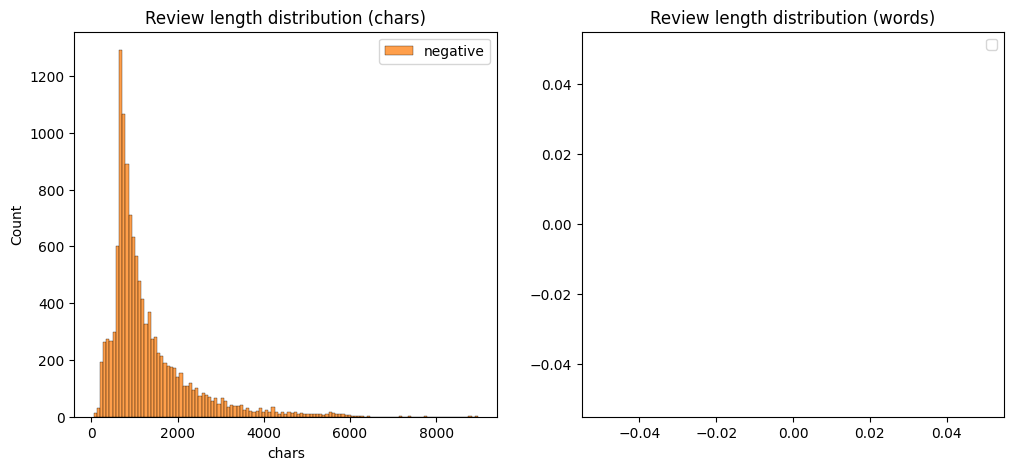

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['chars'], ax=axs[0], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 0]['chars'], ax=axs[0], label='negative')
axs[0].set_title("Review length distribution (chars)")
axs[0].legend()

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='negative')
axs[1].set_title("Review length distribution (words)")
axs[1].legend()

As can be seen, the distribution of review lengths is quite similar for both positive and negative reviews, with most reviews being below 500 words. In terms of characters, most reviews have less than 3000 characters. This can be confirmed with boxplots, which show the "whiskers" of the distribution and any potential outliers.

Text(0.5, 1.0, 'Review length (words) by sentiment')

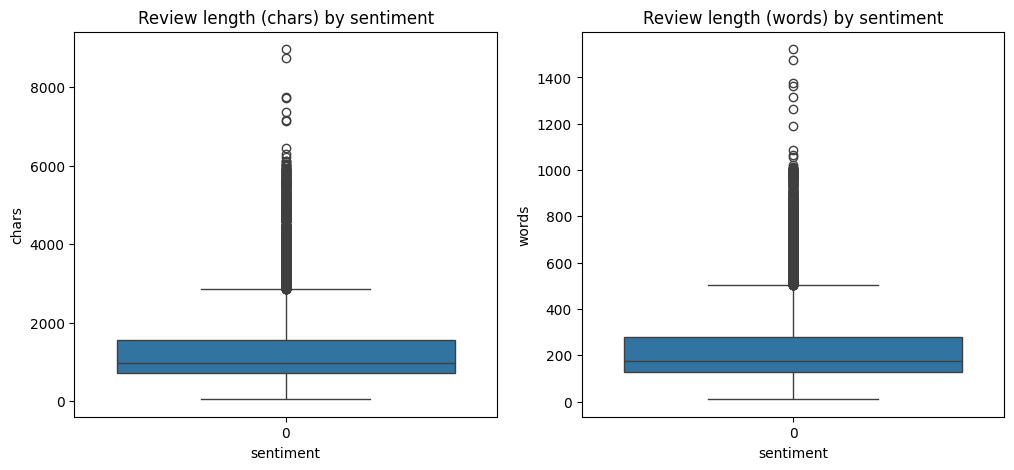

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='sentiment', y='chars', data=review_length_df, ax=axs[0])
axs[0].set_title("Review length (chars) by sentiment")

sns.boxplot(x='sentiment', y='words', data=review_length_df, ax=axs[1])
axs[1].set_title("Review length (words) by sentiment")

In [15]:
def get_top_words(docs, n=20):
    all_words = ' '.join(docs).split()
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [16]:
print("Top words in positive reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 1]['review']))

print("\nTop words in negative reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 0]['review']))

Top words in positive reviews:
[]

Top words in negative reviews:
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'I', 'that', 'this', 'it', '/><br', 'was', 'for', 'with', 'as', 'but', 'movie', 'The', 'on']


As we can see, the most common words in both positive and negative reviews are quite similar, with words like "the", "and", "a", "is" appearing frequently. Another issue is that this is case-insensitive, so "the" is treated as different that "The". To get a better idea of common words by sentiment, we can normalize the text by converting it to lowercase and removing any punctuation (and numbers, while we are at it).

In [17]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [18]:
print("Top words in positive reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']]))

print("\nTop words in negative reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']]))

Top words in positive reviews (normalized):
[]

Top words in negative reviews (normalized):
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'this', 'i', 'it', 'that', 'br', 'was', 'movie', 'for', 'but', 'with', 'as', 'film', 'on']


While most of the common words are still common stop words, at least we are now getting words like "movie" and "film". However, this still doesn't give us a good idea of which words are more associated with positive vs negative reviews.

To deal with this, we will use the NLTK library to remove stop words.

In [19]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [20]:
stopwords = stopwords.words('english')
print(stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

Some of these words are negations, such as "not", "no", "nor", which can be important for sentiment analysis. We will keep these in our list of stop words.

In [21]:
neg_words = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

stopwords = [w for w in stopwords if w not in neg_words]

Let's redefine our `get_top_words` function to remove stop words before counting the most common words.

In [22]:
def get_top_words(docs, n=20, exclude=None):
    all_words = ' '.join(docs).split()
    if exclude is not None:
        all_words = [w for w in all_words if w not in exclude]
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [23]:
# Ensure stopwords are processed in the same way as our documents (lowercased and punctuation removed)
norm_stopwords = set([normalize_text(w) for w in stopwords])

print("Top words in positive reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']], exclude=norm_stopwords))

print("\nTop words in negative reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']], exclude=norm_stopwords))

Top words in positive reviews (no stopwords):
[]

Top words in negative reviews (no stopwords):
['br', 'movie', 'film', 'not', 'one', 'like', 'no', 'even', 'good', 'bad', 'would', 'really', 'time', 'see', 'dont', 'get', 'much', 'story', 'people', 'could']


We can now start to see some differences in the most common words between positive and negative reviews. Words like "good" and "great" are more common in positive reviews, while words like "bad" are now more common in negative reviews. That said, there is still a lot of overlap, since words like "movie", "film" and "story" are expected to appear in movie reviews regardless of the sentiment. We will deal with this later.

## Vectorization

We have now done some basic EDA to understand the data. The next step is to convert the text data into a format that can be used for machine learning models. One common approach is to use a bag-of-words representation, where we create a vector for each document that counts the occurrences of each word in the vocabulary. We can use the `CountVectorizer` from the `sklearn` library to do this.

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words=stopwords, lowercase=True)
x_train = vectorizer.fit_transform(train_df['review'])
x_test = vectorizer.transform(test_df['review'])

Now that we vectorized our text data, let's compare the result with the original text.

In [25]:
print(train_df['review'][0])
print(x_train[0])

Steve Carpenter cannot make horror movies. First of all, the casting was very wrong for this movie. The only decent part was the hot brown haired girl from Buffy the Vampire Slayer. This movies has no gore(usually a key ingredient to a horror movie), no action, no acting, and no suspense(also a key ingredient). Wes Bentley is a good actor but he is so dry and plain in this that it's sad. There were a few parts that were supposed to be funny(continuing the teen horror/comedy movies) and no one laughed in the audience. I thought that this movie was rated R, and I didn't pay attention and realized it had been changed to PG-13. Anyway, see this movie if you liked I Still Know What You Did Last Summer. That's the only type of person who would find this movie even remotely scary. And seriously, this is to you Steve Carpenter, stop making horror movies. This movie makes Scream look like Texas Chainsaw Massacre.
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 77 stored elements and

We can see that the vectorizer converts every review into a sparse vector of word counts, where the length of the vector is equal to the size of the vocabulary (the number of unique words in the training set after removing stop words). The `fit_transform` method learns the vocabulary from the training data and transforms it into vectors, while the `transform` method uses the same vocabulary to transform the test data.

Each element in the vector corresponds to a word in the vocabulary, and the value of that element is the count of how many times that word appears in the review. Since most reviews will only contain a small subset of the total vocabulary, these vectors are typically very sparse (mostly zeros), which is why they are stored in a sparse format.

Let's get the list of words that are present in the first review and their corresponding counts.

In [26]:
vec = x_train[0].toarray()[0].tolist()
word_count = [(idx, count) for idx, count in enumerate(vec) if count > 0]
print(word_count)

[(90, 1), (1154, 1), (1157, 1), (1178, 1), (2041, 1), (2702, 1), (3532, 1), (3587, 1), (4958, 1), (6664, 1), (6808, 1), (7468, 1), (7703, 2), (7835, 1), (8169, 1), (8236, 1), (9667, 1), (10460, 1), (12242, 1), (13280, 1), (14763, 1), (16529, 1), (17936, 1), (18016, 1), (19225, 1), (20030, 1), (20402, 1), (20466, 1), (21394, 1), (22990, 4), (23052, 1), (24452, 2), (26413, 2), (26760, 1), (27345, 1), (27399, 1), (27995, 1), (27998, 1), (28433, 1), (29157, 1), (29166, 1), (29174, 1), (29732, 1), (31778, 6), (31790, 4), (32950, 5), (33761, 1), (34917, 1), (34959, 1), (35147, 1), (35538, 1), (35670, 1), (36147, 1), (38637, 1), (38802, 1), (39529, 1), (41153, 1), (41693, 1), (42002, 1), (42255, 1), (42537, 1), (43888, 1), (45698, 2), (45744, 1), (45873, 1), (46568, 1), (46746, 1), (46879, 1), (47708, 1), (48013, 1), (48253, 1), (49804, 1), (51067, 1), (51208, 1), (52553, 1), (53344, 1), (53449, 1)]


The previous cell gives us a list of tuples, where each tuple contains the index of a word in the vocabulary and the count of that word in the first review. To get the actual words, we can use the `get_feature_names_out` method of the vectorizer to get the list of words in the vocabulary and then map the indices to words.

In [27]:
for idx, count in word_count:
    print(f"{vectorizer.get_feature_names_out()[idx]}: {count}")

13: 1
acting: 1
action: 1
actor: 1
also: 1
anyway: 1
attention: 1
audience: 1
bentley: 1
brown: 1
buffy: 1
cannot: 1
carpenter: 2
casting: 1
chainsaw: 1
changed: 1
comedy: 1
continuing: 1
decent: 1
didn: 1
dry: 1
even: 1
find: 1
first: 1
funny: 1
girl: 1
good: 1
gore: 1
haired: 1
horror: 4
hot: 1
ingredient: 2
key: 2
know: 1
last: 1
laughed: 1
like: 1
liked: 1
look: 1
make: 1
makes: 1
making: 1
massacre: 1
movie: 6
movies: 4
no: 5
one: 1
part: 1
parts: 1
pay: 1
person: 1
pg: 1
plain: 1
rated: 1
realized: 1
remotely: 1
sad: 1
scary: 1
scream: 1
see: 1
seriously: 1
slayer: 1
steve: 2
still: 1
stop: 1
summer: 1
supposed: 1
suspense: 1
teen: 1
texas: 1
thought: 1
type: 1
usually: 1
vampire: 1
wes: 1
would: 1
wrong: 1


One problem with CountVectorizer is that it gives equal weight to all words, regardless of how common they are across the entire corpus. This can lead to issues where very common words (like "movie", "film", "story") dominate the representation, even though they may not be very informative for distinguishing between positive and negative reviews. To address this, we can use the `TfidfVectorizer`, which stands for Term Frequency-Inverse Document Frequency. This vectorizer gives more weight to words that are more unique to a particular document and less weight to words that are common across all documents.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords, lowercase=True)
x_train_tfidf = tfidf_vectorizer.fit_transform(train_df['review'])
x_test_tfidf = tfidf_vectorizer.transform(test_df['review'])

Now let's compare the TF-IDF representation with the original text and the CountVectorizer representation.

In [29]:
review_no_stopwords = ' '.join([w for w in train_df['review'][1].split() if w.lower() not in stopwords])
print("Original review:\n", train_df['review'][1])

print("\nOriginal review (no stopwords):\n", review_no_stopwords)

print("\nAs token IDs:\n", [vectorizer.vocabulary_.get(w.lower(), "-") for w in review_no_stopwords.split()])

Original review:
 I saw this film at the Rotterdam Festival, as did presumably all the other voters. The Director was present and seemed to have worked very hard and be very committed to the project, which I think explains the above average reception and mark it got. It's most similar to a feature length episode of Aussie kids favourite "Round the Twist" but it takes itself too seriously to have even that redeeming feature. The movie in itself is maybe worth seeing if you're trying to do a cinematic world tour visiting all UN member states, as I can't think of another Fijian movie but overall it was generic, poorly acted (albeit by an amateur cast) and prey to the subaltern mentality. The moral of the story seemed to be that native islanders will try and screw each other over, but as long as there is an essentially decent white governor to step in, all problems can be solved (by leaving the island).

Original review (no stopwords):
 saw film Rotterdam Festival, presumably voters. Direc

## Training a model

Let's train a simple logistic regression model for this dataset.

To compare models fairly, we will keep the exact same logistic regression hyperparameters across all runs. Since reviews are loaded with all positives first and all negatives after, we will shuffle train/test once before running experiments so quick spot-checks are easier to interpret.

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

RANDOM_STATE = 42

# Ensures dataset is shuffled
train_exp_df = train_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_exp_df = test_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


In [31]:
def run_experiment(vectorizer, preprocess_fn=None):
    train_text = train_exp_df['review']
    test_text = test_exp_df['review']

    if preprocess_fn is not None:
        train_text = train_text.apply(preprocess_fn)
        test_text = test_text.apply(preprocess_fn)

    x_train_vec = vectorizer.fit_transform(train_text)
    y_train = train_exp_df['sentiment']

    x_test_vec = vectorizer.transform(test_text)
    y_test = test_exp_df['sentiment']

    model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)
    model.fit(x_train_vec, y_train)
    y_test_pred = model.predict(x_test_vec)
    y_train_pred = model.predict(x_train_vec)

    metrics = {
        'accuracy_train': accuracy_score(y_train, y_train_pred),
        'accuracy_test': accuracy_score(y_test, y_test_pred),
        'precision_train': precision_score(y_train, y_train_pred),
        'precision_test': precision_score(y_test, y_test_pred),
        'recall_train': recall_score(y_train, y_train_pred),
        'recall_test': recall_score(y_test, y_test_pred),
        'f1_train': f1_score(y_train, y_train_pred),
        'f1_test': f1_score(y_test, y_test_pred),
    }

    return model, vectorizer, metrics


In [32]:
experiments = [
    ('CountVectorizer', None, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-norm', normalize_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer', None, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-norm', normalize_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

results = []
model_runs = []
for exp_name, preprocess_fn, vectorizer in experiments:
    model, fitted_vectorizer, metrics = run_experiment(vectorizer, preprocess_fn=preprocess_fn)
    results.append({
        'vectorizer': exp_name,
        **metrics,
    })
    model_runs.append({
        'name': exp_name,
        'model': model,
        'fitted_vectorizer': fitted_vectorizer,
    })

results_df = pd.DataFrame(results).sort_values('accuracy_test', ascending=False)
results_df


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)

The table above compares all four configurations using the same logistic regression setup. You can use it to identify whether TF-IDF or CountVectorizer works better here, and whether applying `normalize_text` helps or hurts performance.



We can also look at the most important features for each model to see which words are driving the predictions. For logistic regression, we can look at the coefficients of the model to identify the most influential words for positive and negative sentiment.

As a reminder, a logistic regression model computes scores between 0 and 1 using a linear equation, where each feature has a coefficient. The higher the coefficient, the more that feature contributes to predicting the positive class (sentiment=1), while a lower coefficient contributes to predicting the negative class (sentiment=0). Since each feature represents a word in the vocabulary, we can look at the coefficients to see which words are most strongly associated with positive and negative reviews.

In [ ]:
def get_top_features(model, fitted_vectorizer, top_n=10):
    feature_names = fitted_vectorizer.get_feature_names_out()
    coefs = model.coef_[0]

    top_pos_idx = coefs.argsort()[::-1][:top_n]
    top_neg_idx = coefs.argsort()[:top_n]

    top_positive = [(feature_names[idx], coefs[idx]) for idx in top_pos_idx]
    top_negative = [(feature_names[idx], coefs[idx]) for idx in top_neg_idx]
    return top_positive, top_negative

def print_compact_feature_table(model_runs, sentiment='positive', top_n=10):
    table_data = {}

    for run in model_runs:
        top_positive, top_negative = get_top_features(run['model'], run['fitted_vectorizer'], top_n=top_n)
        selected = top_positive if sentiment == 'positive' else top_negative
        table_data[run['name']] = [f"{word} ({coef:.3f})" for word, coef in selected]

    compact_df = pd.DataFrame(table_data, index=[f"#{i}" for i in range(1, top_n + 1)])
    compact_df.index.name = 'rank'
    display(compact_df)

print('Top 10 positive words across experiments')
print_compact_feature_table(model_runs, sentiment='positive', top_n=10)

print('\nTop 10 negative words across experiments')
print_compact_feature_table(model_runs, sentiment='negative', top_n=10)

## Activity

#### Run 4 new experiments: 2 with CountVectorizer and 2 with TfidfVectorizer. For each vectorizer, apply stemming and lemmatization as the first step of your preprocessing function. Display the models metrics and top features as before.

#### Which vectorizer and preprocessing combination gives the best performance? Do you see any interesting differences in the top features across the different models?

#### Write a review for the latest movie that you have seen. Then, use the best performing model to predict the sentiment of your review. Do you agree with the model's prediction? Why or why not?

#### Write your final remarks on this activity.